In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.sandbox.regression.predstd import wls_prediction_std

np.random.seed(42)

In [17]:
#Fake data 1
nsample = 100
x = np.linspace(0,10,100)
X = np.column_stack((x,x**2))
beta = np.array([1,0.1,10])
e = np.random.normal(size=nsample)

In [18]:
X = sm.add_constant(X)
y = np.dot(X, beta) + e

In [19]:
res = sm.OLS(y, X).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.437e+06
Date:                Sun, 21 Jun 2026   Prob (F-statistic):          1.24e-245
Time:                        18:55:09   Log-Likelihood:                -131.47
No. Observations:                 100   AIC:                             268.9
Df Residuals:                      97   BIC:                             276.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9481      0.269      3.524      0.001       0.414       1.482
x1             0.0405      0.124      0.326      0.745      -0.206       0.287
x2            10.0073      0.012    831.696      0.000       9.983      10.031
==============================================================================
Omnibus:                        0.407   Durbin-Watson:                   2.050
Prob(Omnibus):                  0.816   Jarque-Bera (JB):                0.431
Skew:                          -0.147   Prob(JB):                        0.806
Kurtosis:                       2.872   Cond. No.                         144.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
print("R2:",res.rsquared)

R2: 0.9999910791623945


OLS WITH A NON-LINEAR CURVE BUT LINEAR PARAMETERS

In [21]:
#Fake data 2
nsample = 100
sig = 0.5
x = np.linspace(0,10,nsample)
X = np.column_stack((x, np.sin(x), (x-5)**2, np.ones(nsample)))
beta = np.array([0.5,0.5,-0.02,5.])
y_true = np.dot(X, beta)
y = y_true + sig * np.random.normal(size=nsample)   #Adds noise

In [22]:
res_2 = sm.OLS(y, X).fit()
res_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     327.8
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           2.69e-50
Time:                        18:55:09   Log-Likelihood:                -65.291
No. Observations:                 100   AIC:                             138.6
Df Residuals:                      96   BIC:                             149.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.5034      0.016     30.830      0.000       0.471       0.536
x2             0.6380      0.078      8.139      0.000       0.482       0.794
x3            -0.0308      0.007     -4.510      0.000      -0.044      -0.017
const          5.0614      0.108     46.807      0.000       4.847       5.276
==============================================================================
Omnibus:                        1.566   Durbin-Watson:                   2.235
Prob(Omnibus):                  0.457   Jarque-Bera (JB):                1.562
Skew:                           0.291   Prob(JB):                        0.458
Kurtosis:                       2.810   Cond. No.                         27.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:
print("Parameters:", res_2.params)
print("Std Errors:", res_2.bse)
print("Pred Values:", res_2.predict())
print("R Squared:", res_2.rsquared)

Parameters: [ 0.50339563  0.63796746 -0.03081733  5.0614168 ]
Std Errors: [0.01632802 0.07838236 0.00683309 0.10813273]
Pred Values: [4.29098365 4.43697751 4.58168668 4.72446204 4.86466775 5.00168777
 5.13493211 5.26384288 5.38789993 5.50662622 5.61959259 5.72642224
 5.82679448 5.92044807 6.00718381 6.08686667 6.15942705 6.22486159
 6.28323314 6.33467015 6.37936536 6.41757381 6.44961027 6.47584601
 6.49670504 6.51265976 6.52422615 6.53195853 6.53644388 6.53829587
 6.53814863 6.53665022 6.5344561  6.53222239 6.53059922 6.53022406
 6.53171526 6.53566575 6.54263695 6.55315308 6.56769584 6.58669942
 6.61054618 6.63956264 6.67401626 6.71411261 6.75999338 6.81173483
 6.86934709 6.93277403 7.00189383 7.0765202  7.15640435 7.24123744
 7.33065378 7.42423455 7.52151207 7.62197454 7.72507131 7.83021845
 7.93680471 8.04419777 8.15175067 8.2588084  8.36471462 8.46881827
 8.5704803  8.6690801  8.76402191 8.85474081 8.94070853 9.02143885
 9.09649251 9.16548169 9.22807402 9.28399591 9.33303537 9.37504

In [26]:
def plot_compare(res):
    prstd, iv_1, iv_u = wls_prediction_std(res)
    fig, ax = plt.subplots(figsize=(10,6))

    ax.plot(x, y, 'o', label='data')
    ax.plot(x, y_true, 'b--', label="True")
    ax.plot(x, res.fittedvalues, 'r--', label="OLS")
    ax.plot(x, iv_u, 'g--', label="Error")
    ax.plot(x, iv_1, 'g--')
    ax.legend(loc="best")

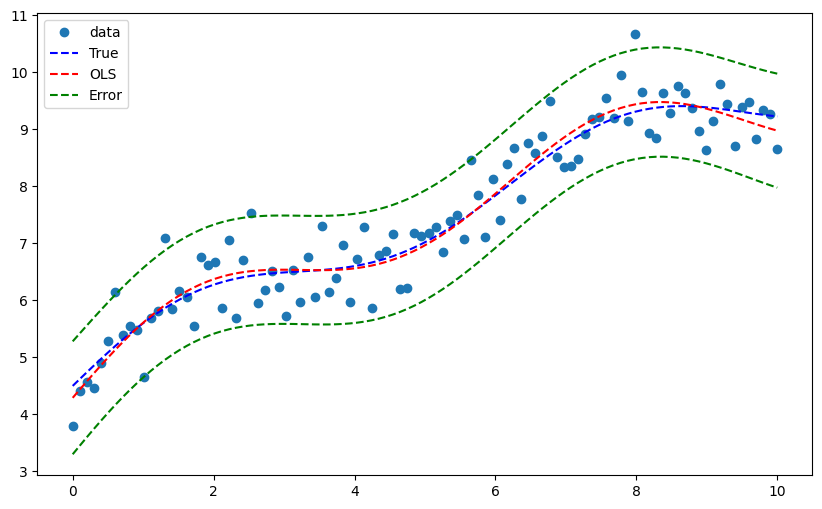

In [27]:
plot_compare(res_2)